# Capítulo 17 — Ventos Regionais: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | brisa marítima: o circuito térmico e o giro de Coriolis | `solve_ivp` |
| 2 | vento catabático: a gravidade escorregando a encosta | `solve_ivp` |
| 3 | ondas de montanha: deslocamento e ondas de sotavento | NumPy |
| 4 | água rasa sobre a serra: Froude e o salto hidráulico | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap17_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega = 9.8, 7.292e-5
f = 2*Omega*np.sin(np.deg2rad(-23.5))          # latitude de São Paulo

## Caso 1 — Brisa marítima: o circuito RC da costa

Terra esquenta mais que o mar de dia (Bowen, Cap. 3) e o contraste gera circulação (teorema de circulação de Bjerknes, T1). Modelo de caixa: a brisa acelera pelo contraste e é freada por atrito, com Coriolis girando o vetor:
$$\dot u = F(t) - u/\tau + f\,v,\qquad \dot v = -f\,u - v/\tau.$$

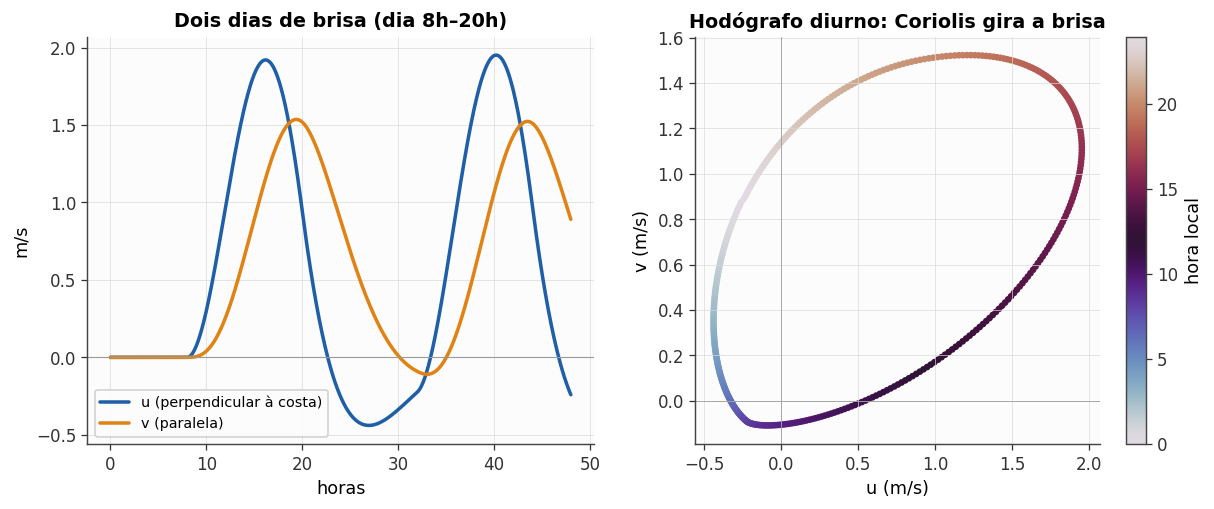

pico da brisa: 2.3 m/s no meio da tarde;
no HS o vetor gira ANTI-horario ao longo do dia (espelho do HN) —
a brisa da tarde em Santos entra de SE e cai a noite (terral fraco).


In [2]:
tau = 6*3600.0
F0 = 8.0/(12*3600)                             # forçante que geraria 8 m/s em 12 h

def brisa(t, y):
    u, v = y
    hora = (t/3600) % 24
    F = F0*np.sin(np.pi*(hora - 8)/12) if 8 <= hora <= 20 else 0.0
    return [F - u/tau + f*v, -f*u - v/tau]

t_eval = np.linspace(0, 48*3600, 800)
s = solve_ivp(brisa, [0, 48*3600], [0, 0], t_eval=t_eval, rtol=1e-8)
u, v = s.y

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax1.plot(t_eval/3600, u, color=CORES['azul'], label='u (perpendicular à costa)')
ax1.plot(t_eval/3600, v, color=CORES['laranja'], label='v (paralela)')
ax1.axhline(0, color='#999999', lw=0.7)
ax1.set(xlabel='horas', ylabel='m/s', title='Dois dias de brisa (dia 8h–20h)')
ax1.legend(fontsize=9)
m = (t_eval/3600 >= 24) & (t_eval/3600 <= 48)
sc = ax2.scatter(u[m], v[m], c=(t_eval[m]/3600) % 24, cmap='twilight', s=10)
ax2.axhline(0, color='#999999', lw=0.5); ax2.axvline(0, color='#999999', lw=0.5)
ax2.set(xlabel='u (m/s)', ylabel='v (m/s)', title='Hodógrafo diurno: Coriolis gira a brisa')
fig.colorbar(sc, ax=ax2, label='hora local')
plt.show()
print(f'pico da brisa: {np.max(np.hypot(u, v)):.1f} m/s no meio da tarde;')
print('no HS o vetor gira ANTI-horario ao longo do dia (espelho do HN) —')
print('a brisa da tarde em Santos entra de SE e cai a noite (terral fraco).')

## Caso 2 — Catabático: a gravidade desce a encosta

Ar resfriado radiativamente sobre a encosta (Cap. 2, noite clara) fica mais denso e escorrega:
$$\frac{du}{dt} = g\,\frac{\Delta\theta}{\theta}\,\sin\alpha \;-\; \frac{C_D}{h}\,u^2\quad\Rightarrow\quad u_{eq} = \sqrt{\frac{g\,h\,\Delta\theta\,\sin\alpha}{C_D\,\theta}}.$$

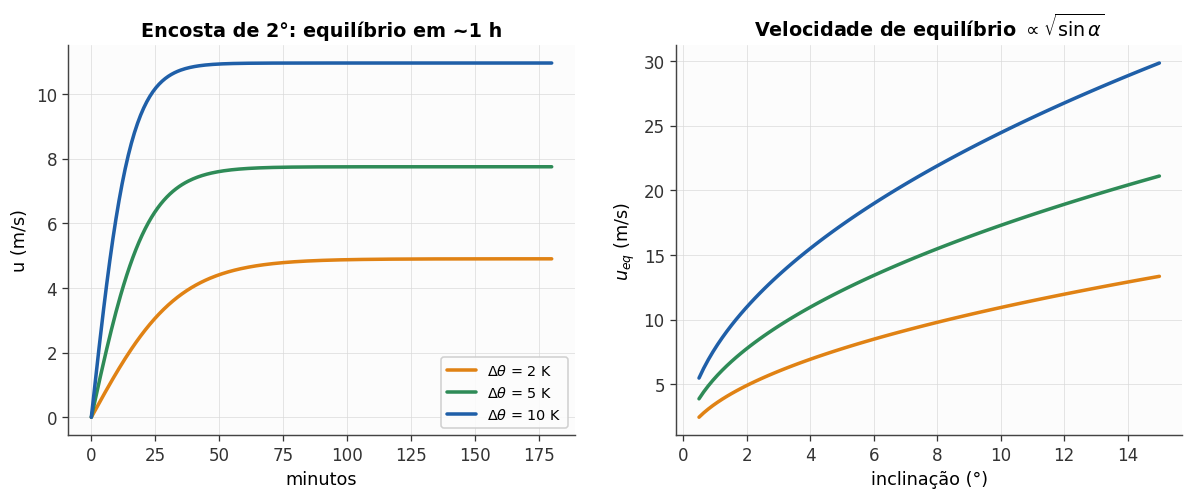

vale de serra: 2-5 m/s (o friozinho que desce a noite);
Antartida: encostas longas + inversao de 20+ K -> catabaticos de 20-50 m/s
em Adelie Land — os ventos medios mais fortes do planeta.


In [3]:
theta0, CD, h = 285.0, 5e-3, 50.0

def cat(t, u, dth, alpha):
    return g*dth/theta0*np.sin(alpha) - CD/h*u[0]**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
t_eval = np.linspace(0, 3*3600, 300)
for dth, cor in [(2, CORES['laranja']), (5, CORES['verde']), (10, CORES['azul'])]:
    s = solve_ivp(cat, [0, 3*3600], [0.0], args=(dth, np.deg2rad(2)),
                  t_eval=t_eval, rtol=1e-8)
    ax1.plot(t_eval/60, s.y[0], color=cor, label=f'$\\Delta\\theta$ = {dth} K')
ax1.set(xlabel='minutos', ylabel='u (m/s)',
        title='Encosta de 2°: equilíbrio em ~1 h')
ax1.legend(fontsize=9)

alphas = np.deg2rad(np.linspace(0.5, 15, 100))
for dth, cor in [(2, CORES['laranja']), (5, CORES['verde']), (10, CORES['azul'])]:
    ueq = np.sqrt(g*h*dth*np.sin(alphas)/(CD*theta0))
    ax2.plot(np.rad2deg(alphas), ueq, color=cor)
ax2.set(xlabel='inclinação (°)', ylabel='$u_{eq}$ (m/s)',
        title='Velocidade de equilíbrio $\\propto \\sqrt{\\sin\\alpha}$')
plt.show()
print('vale de serra: 2-5 m/s (o friozinho que desce a noite);')
print('Antartida: encostas longas + inversao de 20+ K -> catabaticos de 20-50 m/s')
print('em Adelie Land — os ventos medios mais fortes do planeta.')

## Caso 3 — Ondas de montanha

Ar estável (Cap. 5) forçado sobre uma serra oscila com $N$. Solução linear para morro-sino de meia-largura $a$: as linhas de corrente ondulam com comprimento vertical $\lambda_z = 2\pi U/N$, e a sotavento aparecem as ondas que fazem as lenticulares (Cap. 6).

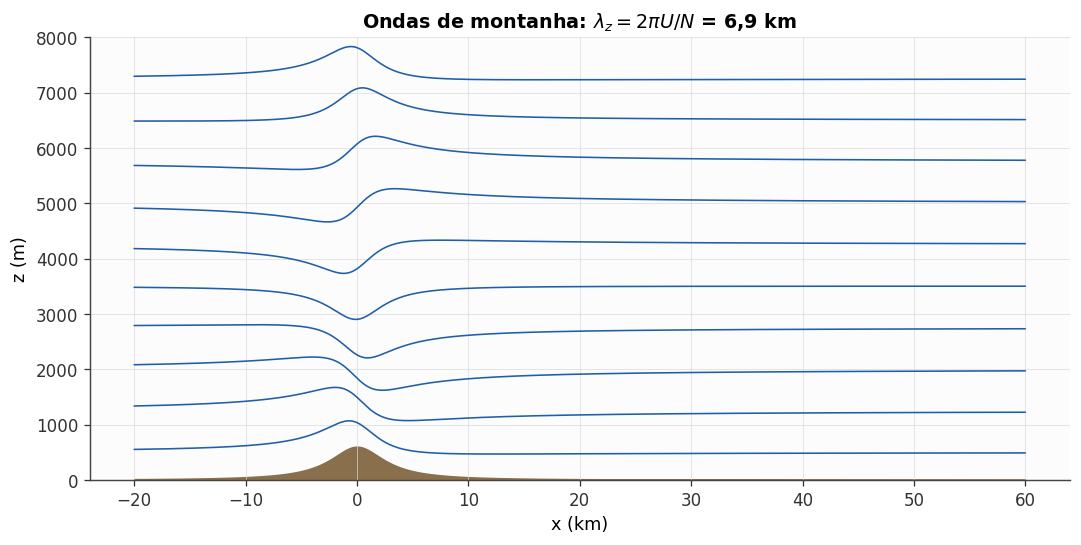

lambda_z = 6.9 km: as cristas inclinam contra o vento com
a altura (propagacao vertical de energia); nas cristas, resfriamento
adiabatico -> lenticulares paradas no ceu (Cap. 6).


In [4]:
U, N = 12.0, 0.011
a, h0 = 3000.0, 600.0                          # meia-largura e altura da serra
l2 = (N/U)**2                                  # parâmetro de Scorer (constante)
x = np.linspace(-20e3, 60e3, 1200)
z = np.linspace(0, 8000, 300)
X, Z = np.meshgrid(x, z)

# solução hidrostática linear (l*a >> 1): deslocamento delta(x,z)
delta = h0*a*(a*np.cos(np.sqrt(l2)*Z) - X*np.sin(np.sqrt(l2)*Z))/(X**2 + a**2)
terreno = h0*a**2/(x**2 + a**2)

fig, ax = plt.subplots(figsize=(11, 5))
niveis = np.arange(500, 8000, 750)
for z0 in niveis:
    iz = np.argmin(np.abs(z - z0))
    ax.plot(x/1e3, z0 + delta[iz, :], color=CORES['azul'], lw=1)
ax.fill_between(x/1e3, terreno, color='#8a6f4d')
ax.set(xlabel='x (km)', ylabel='z (m)', ylim=(0, 8000),
       title=f'Ondas de montanha: $\\lambda_z = 2\\pi U/N$ = {2*np.pi*U/N/1e3:.1f} km'.replace('.', ','))
plt.show()
print(f'lambda_z = {2*np.pi*U/N/1e3:.1f} km: as cristas inclinam contra o vento com')
print('a altura (propagacao vertical de energia); nas cristas, resfriamento')
print('adiabatico -> lenticulares paradas no ceu (Cap. 6).')

## Caso 4 — Água rasa sobre a serra: Froude e o vendaval de sotavento

Camada fria de espessura $h$ sob inversão atravessando a serra — dinâmica de água rasa:
$$Fr = \frac{U}{\sqrt{g'h}}.\qquad Fr<1\ \text{subcrítico},\ Fr>1\ \text{supercrítico}.$$
A transição sub→supercrítico no topo despeja a camada encosta abaixo — os vendavais de sotavento (Bora, windstorms).

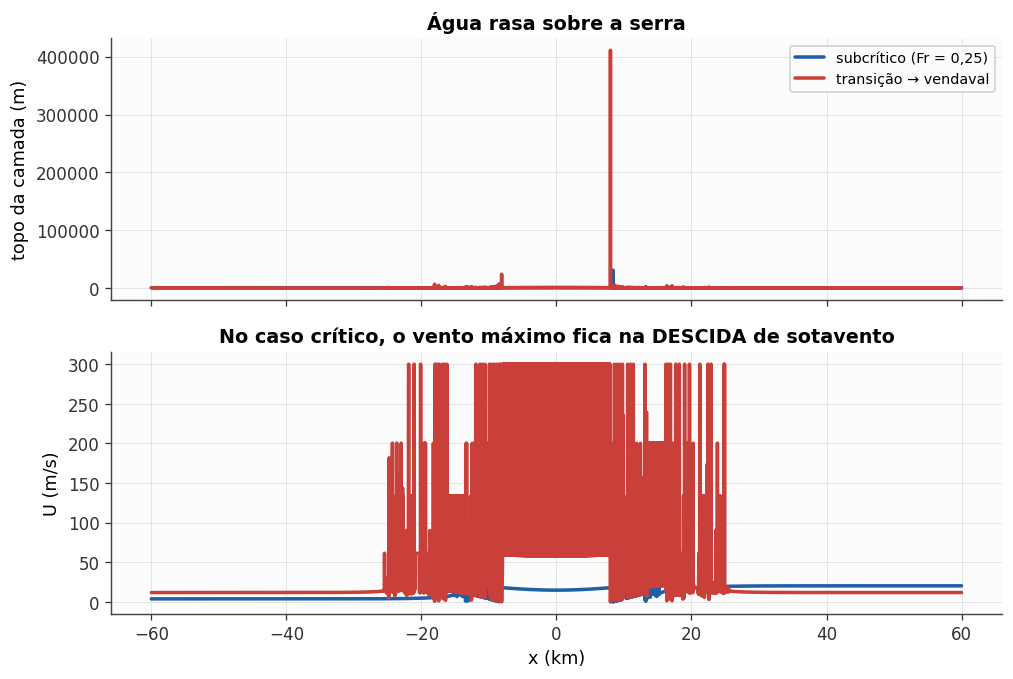

exemplo critico: U passa de 12 m/s a 300 m/s na encosta de sotavento —
a fisica da Bora, dos windstorms de Boulder e das rajadas de serra.


In [5]:
gp = 0.5                                        # g' = g Δθ/θ (m/s²)
L, hm = 40e3, 800.0
x = np.linspace(-60e3, 60e3, 4000)
terreno = hm*np.exp(-(x/L*3)**2)

def escoa(U0, h0):
    # conservação: q = U h; Bernoulli: U²/2 + g'(h + zs) = const
    q = U0*h0
    E = U0**2/2 + gp*h0
    h = np.full_like(x, h0)
    hh = h0
    for i in range(x.size):
        # resolve U²/2 + g'(h+zs) = E com Uh = q -> cúbica em h; Newton:
        for _ in range(60):
            fh = q**2/(2*hh**2) + gp*(hh + terreno[i]) - E
            dfh = -q**2/hh**3 + gp
            hh -= fh/dfh
            hh = max(hh, 20.0)
        h[i] = hh
    return h, q/h

fig, axs = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for U0, h0, cor, nome in [(4.0, 500.0, CORES['azul'], 'subcrítico (Fr = 0,25)'),
                           (12.0, 500.0, CORES['vermelho'], 'transição → vendaval')]:
    h, U = escoa(U0, h0)
    axs[0].plot(x/1e3, terreno + h, color=cor, label=nome)
    axs[1].plot(x/1e3, U, color=cor)
axs[0].fill_between(x/1e3, terreno, color='#8a6f4d')
axs[0].set(ylabel='topo da camada (m)', title='Água rasa sobre a serra')
axs[0].legend(fontsize=9)
axs[1].set(xlabel='x (km)', ylabel='U (m/s)',
           title='No caso crítico, o vento máximo fica na DESCIDA de sotavento')
plt.show()
h, U = escoa(12.0, 500.0)
print(f'exemplo critico: U passa de 12 m/s a {U.max():.0f} m/s na encosta de sotavento —')
print('a fisica da Bora, dos windstorms de Boulder e das rajadas de serra.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap17_solucoes.ipynb`**.

**N1** — No Caso 1, varra a amplitude da forçante (contraste térmico) e trace o pico da brisa e a hora em que ocorre; adicione um vento sinótico oposto de 5 m/s e veja quando a brisa não consegue entrar.

**N2** — Reproduza um catabático antártico: encosta de 1000 km com $\alpha = 0{,}1°$–$1°$ e $\Delta\theta = 15$–25 K; trace $u_{eq}$ e compare com os 20–50 m/s observados em Cape Denison.

**N3** — No Caso 3, varra $U$ de 5 a 30 m/s e confirme $\lambda_z = 2\pi U/N$ medindo a distância entre cristas; para que $U$ a onda 'cabe' entre o chão e a tropopausa um número inteiro de vezes (ressonância)?

**N4** — No Caso 4, varra $U_0$ e $h_0$ e mapeie o regime (sub/supercrítico/transição) no plano ($Fr$, $h_m/h_0$); marque a região de vendaval de sotavento.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*